### Grading
This week's lab doesn't have any auto-graded components. Each question in this notebook has an accompanying Peer Review question. Although the lab shows as being ungraded, you need to complete the notebook to answer the Peer Review questions. <br>
**DO NOT CHANGE VARIABLE OR METHOD SIGNATURES** 

### Validate Button
This week's lab doesn't have any auto-graded components. Each question in this notebook has an accompanying Peer Review question. Although the lab shows as being ungraded, you need to complete the notebook to answer the Peer Review questions. 

You do not need to use the Validate button for this lab since there are no auto-graded components. If you hit the Validate button, it will time out given the number of visualizations in the notebook. Cells with longer execution times cause the validate button to time out and freeze. ***This notebook's Validate button time-out does not affect the final submission grading.*** 

# Clustering RNA sequences to identify cancer types

In this assignment, we will use clustering algorithms on RNA sequence data to identify cancer types.
Since the [whole data](https://www.synapse.org/#!Synapse:syn4301332) (from [Cancer Genome Atlas Pan-Cancer project](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3919969/)) is very big, we will use a [subset data from UCI Machine Learning repository](https://archive.ics.uci.edu/ml/datasets/gene+expression+cancer+RNA-Seq#). The subset data contains only 5 labels; BRCA, KIRC, COAD, LUAD and PRAD. The meanings of those labels are as below.

|Abbreviation|Cancer|
|:----:|:-------:|
|LUSC|Lung squamous cell carcinoma |
|READ |Rectum adenocarcinoma |
|GBM |Glioblastoma multiforme|
|BLCA |Bladder Urothelial Carcinoma|
|UCEC |Uterine Corpus Endometrioid Carcinoma|
|COAD |Colon adenocarcinoma|
|OV |Ovarian serous cystadenocarcinoma|
|LAML |Acute Myeloid Leukemia|
|HNSC |Head and Neck squamous cell carcinoma|
|LUAD |Lung adenocarcinoma|
|BRCA |Breast invasive carcinoma|
|KIRC |Kidney renal clear cell carcinoma|

Although we can use the data for supervised learning model training, we will not use these labels for training, but use them for evaluation.

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import accuracy_score, confusion_matrix
import time

In [75]:
# Read data. Do not change the variable names (data, label)
data = pd.read_csv('data/data.csv')
label = pd.read_csv('data/labels.csv')
data=data.drop('Unnamed: 0',axis=1)
label=label.drop('Unnamed: 0',axis=1)

### A. [Peer Review] Perform basic data inspection or EDA on the pandas dataframe.
- How many observations?
- How many features?

In [76]:
# perform basic data inspection such as getting the number of observations and number of features
# you can also display part of the dataframe or run data.info() 
# your code here
print(data.info())
print(label.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Columns: 20531 entries, gene_0 to gene_20530
dtypes: float64(20531)
memory usage: 125.5 MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Class   801 non-null    object
dtypes: object(1)
memory usage: 6.4+ KB
None


- Draw histograms of mean, max and min values in each feature. You may see numbers around 0-20. What do those numbers mean? (We do not expect students to know or figure out the meanings, but if you do know by chance, feel free to discuss them with the class on the discussion board.) <br>
Answer the Peer Review question about this section. 

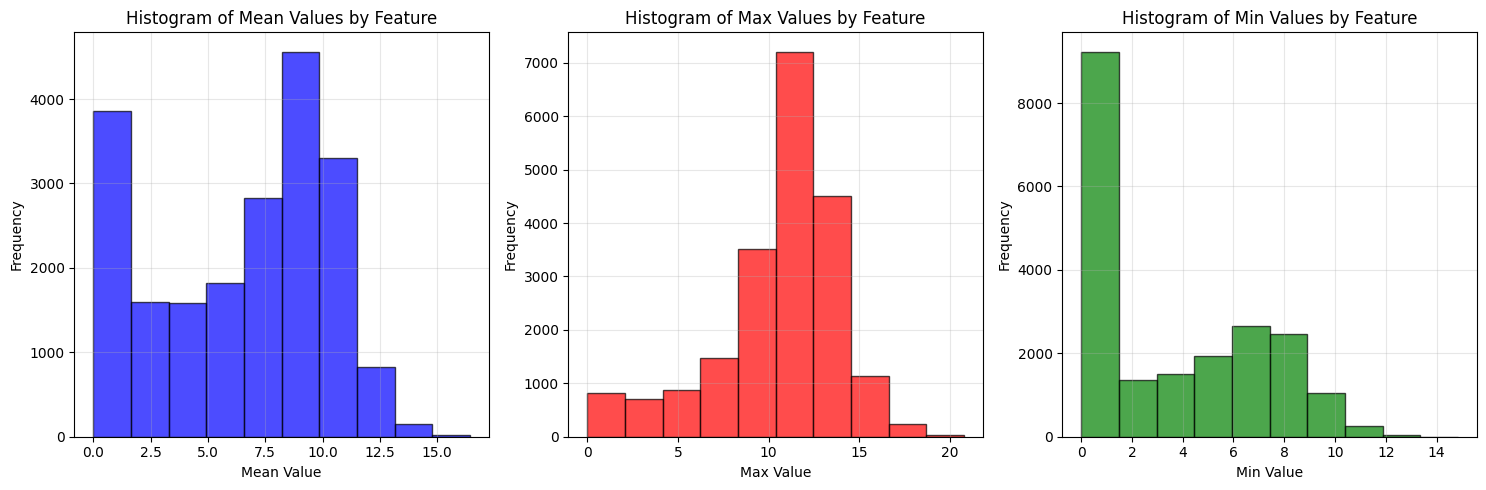

In [77]:
# Calculate statistics for each feature
feature_stats = {
    'mean': data.mean(),
    'max': data.max(),
    'min': data.min()
}

# Create histograms for mean, max, and min values
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot histogram of mean values
axes[0].hist(feature_stats['mean'], bins=10, alpha=0.7, color='blue', edgecolor='black')
axes[0].set_title('Histogram of Mean Values by Feature')
axes[0].set_xlabel('Mean Value')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Plot histogram of max values
axes[1].hist(feature_stats['max'], bins=10, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title('Histogram of Max Values by Feature')
axes[1].set_xlabel('Max Value')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

# Plot histogram of min values
axes[2].hist(feature_stats['min'], bins=10, alpha=0.7, color='green', edgecolor='black')
axes[2].set_title('Histogram of Min Values by Feature')
axes[2].set_xlabel('Min Value')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


- If we were to train a "supervised" learning model, how would you deal with such large feature dimension? 
- Even after feature dimension reduction, still the number of useful features may be enormous. How it would impact performance or runtime of certain supervised learning algorithms? Which algorithms would suffer from high dimension features than others and why? 
- How it would impact performance or runtime of an unsupervised learning algorithm?
- Draw histograms of mean, max and min values in each feature. You may see numbers around 0-20. What those numbers mean? (We do not expect students to know or figure out the meanings, but if you do know by chance, feel free to discuss them with the class on the discussion board.) <br> <br>
Anwer these questions in this week's Peer Review assignment. 

### B. [Peer Review] Build a hierarchical clustering model
Let's build a model using hierarchical clustering. Hierarchical clustering module is available from `sklearn.cluster.AgglomerativeClustering`. You can choose linkage type and metric. Please check its documentation for more details.

**a) Number of clusters vs distance threshold**
Oftentimes hierarchical clustering does not need to know the number of clusters in advance. Instead, one needs to choose threshold distance/similarity to cut the dendrogram later. The AgglomerativeClustering module lets you specify either the number of clusters (n_clusters) or the threshold (distance_threshold). Based on our data, which should we choose to set to which value and why? <br> <br>
Answer this question in the Peer Review assignment. 

#### b) Guess which metric?
Can you guess which metric to use (distance-based vs. similarity-based) and why? 
This question is not graded, but we encourage you to share your thoughts with the class. See the ungraded discussion prompt for this week's material. 

#### c) Build a model
Build a model using n_clusters=5 option. Choose any metric and linkage type at first. Display the clustering result labels (you can just print out the result). Do not change the variable (model) name. Answer the question about this section in the Peer Review.

In [92]:
# build a model using n_clusters=5 option
model=None
# your code here
# Build hierarchical clustering model with n_clusters=5
from sklearn.cluster import AgglomerativeClustering
# Create hierarchical clustering model
model = AgglomerativeClustering(
    n_clusters=5,
    linkage='complete',  # Using ward linkage
    metric='euclidean'  # Using euclidean distance
)

# Fit the model and get cluster labels
cluster_labels = model.fit_predict(data)

# Display the clustering result labels
print("Clustering result labels:")
print(cluster_labels)
print(f"\nNumber of samples: {len(cluster_labels)}")
print(f"Number of clusters: {len(np.unique(cluster_labels))}")
print(f"Cluster distribution: {np.bincount(cluster_labels)}")


Clustering result labels:
[4 3 1 4 1 4 0 4 1 4 1 0 4 2 1 1 3 0 0 4 1 0 3 1 0 3 2 1 1 1 1 1 0 3 4 1 0
 3 1 3 0 4 4 0 0 1 4 2 1 3 1 3 1 4 2 1 1 3 0 1 3 0 1 3 4 2 1 4 0 1 0 1 1 3
 1 3 1 0 4 2 1 4 1 1 4 4 1 1 0 1 4 4 1 3 1 4 2 1 4 1 1 0 1 0 3 0 3 3 3 3 4
 1 3 4 1 0 0 0 1 1 3 0 3 1 4 4 4 1 0 1 2 1 2 1 1 0 3 1 0 2 1 4 1 0 3 2 4 1
 3 3 3 3 1 1 3 1 1 4 4 3 4 3 0 1 4 3 2 0 3 1 0 3 1 3 1 1 1 4 1 0 2 0 1 4 4
 4 3 3 1 3 3 0 3 4 3 1 3 1 3 3 1 0 0 0 0 4 2 4 1 3 3 1 4 1 4 1 1 1 3 1 0 3
 0 0 3 1 0 4 1 3 3 4 2 2 0 4 0 3 1 0 0 3 4 4 3 3 0 1 1 2 1 4 3 1 4 0 4 4 4
 1 3 2 3 2 3 4 3 1 1 0 0 1 2 4 0 4 1 1 0 1 1 1 2 3 3 1 1 1 0 0 0 0 3 1 1 0
 1 1 3 4 1 1 2 3 4 1 1 1 2 1 4 1 2 3 3 4 0 1 0 0 3 3 0 1 1 1 3 0 1 1 4 3 0
 1 3 4 0 1 4 2 1 1 1 3 3 3 1 1 4 3 1 0 1 2 3 3 1 0 1 1 1 2 3 2 0 4 0 1 1 0
 3 2 4 3 4 3 0 4 1 2 0 0 2 2 4 1 3 3 0 3 4 1 1 1 3 3 0 3 3 0 2 4 1 3 4 1 2
 1 3 1 1 4 1 4 2 1 3 1 1 3 1 1 1 0 3 4 1 4 0 1 0 2 1 4 3 0 1 1 0 1 3 3 1 4
 2 1 0 3 4 1 4 1 1 1 1 0 3 1 0 1 1 3 3 0 3 4 2 1 0 0 1 4 0 3 3 3 1 4 4 1 4

#### d) Label permuation
In clustering, the labels get assigned randomly, so the label numbering won't match the ground truth necessarily. Write a function below to find best matching label ordering based on the accuracy. Do not change the variable names. Answer the question about this section in the Peer Review. 

In [93]:
import itertools
from sklearn.metrics import accuracy_score

def label_permute_compare(ytdf, yp, n=5):
    """
    ytdf: labels dataframe object
    yp: clustering label prediction output
    Returns permuted label order and accuracy.
    Example output: (3, 4, 1, 2, 0), 0.74
    """
    best_accuracy = 0
    best_permutation = None

    # Get a list of the unique labels - FIXED: use 'Class' instead of 'Cancer'
    true_labels = sorted(ytdf['Class'].unique())
    predicted_labels = sorted(list(set(yp)))

    # Generate all possible permutations of the predicted labels
    permutations = list(itertools.permutations(predicted_labels))

    # Iterate through all permutations
    for perm in permutations:
        # Create a mapping from predicted labels to true labels
        # perm is a permutation of predicted_labels, map each to corresponding true_label
        label_mapping = {pred_label: true_labels[i] for i, pred_label in enumerate(perm)}

        # Apply the mapping to the predicted labels to convert them to true label format
        permuted_yp = [label_mapping[label] for label in yp]

        # Calculate accuracy - FIXED: use 'Class' instead of 'Cancer'
        current_accuracy = accuracy_score(ytdf['Class'], permuted_yp)

        # Update best accuracy and permutation if current is better
        if current_accuracy > best_accuracy:
            best_accuracy = current_accuracy
            best_permutation = perm

    # Convert numpy int64 to regular int for cleaner output
    if best_permutation is not None:
        best_permutation = tuple(int(x) for x in best_permutation)

    return best_permutation, best_accuracy


In [80]:
# import itertools

# def label_permute_compare(ytdf,yp,n=5):
#     """
#     ytdf: labels dataframe object
#     yp: clustering label prediction output
#     Returns permuted label order and accuracy. 
#     Example output: (3, 4, 1, 2, 0), 0.74 
#     """
#     # Get unique labels from ground truth
#     unique_labels = ytdf.iloc[:, 0].unique()
    
#     # Get unique predicted labels
#     unique_predicted = np.unique(yp)
    
#     # Create all possible permutations of predicted labels
#     best_accuracy = 0
#     best_permutation = None
    
#     # Try all permutations of predicted labels
#     for perm in itertools.permutations(unique_predicted):
#         # Create mapping from predicted labels to ground truth labels
#         label_mapping = {}
#         for i, pred_label in enumerate(perm):
#             if i < len(unique_labels):
#                 label_mapping[pred_label] = unique_labels[i]
        
#         # Map predicted labels to ground truth labels
#         mapped_predictions = np.array([label_mapping.get(pred, pred) for pred in yp])
        
#         # Calculate accuracy
#         accuracy = np.mean(mapped_predictions == ytdf.iloc[:, 0].values)
        
#         # Update best result
#         if accuracy > best_accuracy:
#             best_accuracy = accuracy
#             best_permutation = perm
    
#     return best_permutation, best_accuracy

In [94]:
labelorder, acc = label_permute_compare(label, model.labels_)
print(labelorder, acc)

(1, 2, 0, 3, 4) 0.9313358302122348


#### e) Check confusion matrix
Use sklearn's confusion matrix and display the results. Answer the Peer Review question about this section.  

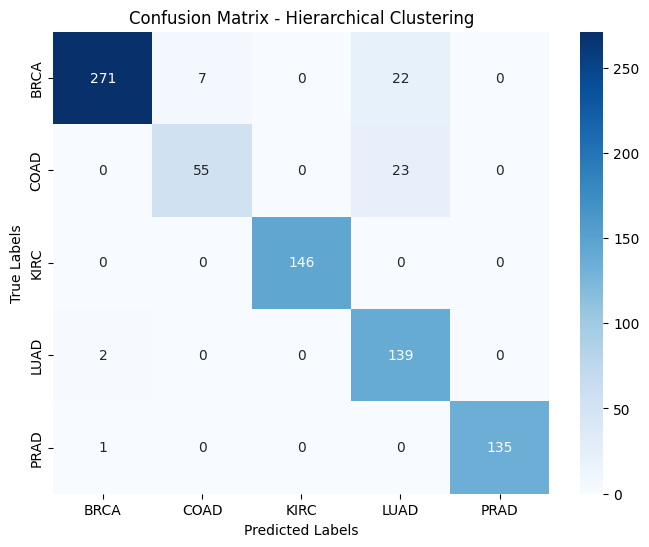

In [95]:
# display confusion matrix here 
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Get the best label mapping
true_labels = sorted(label['Class'].unique())
predicted_labels = sorted(list(set(model.labels_)))
label_mapping = {pred_label: true_labels[i] for i, pred_label in enumerate(labelorder)}
permuted_yp = [label_mapping[label] for label in model.labels_]

# Create confusion matrix - FIXED: use label['Class'] instead of label
cm = confusion_matrix(label['Class'], permuted_yp)

# Display confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=true_labels, yticklabels=true_labels)
plt.title('Confusion Matrix - Hierarchical Clustering')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()



#### f) Change linkage method and distance metric. Which ones lead the best performance? Print out the accuracy and confusion matrix for the best model.
<br> Answer the Peer Review questions about this section. 

Evaluating different linkage methods and distance metrics...
Testing: ward + euclidean
  Accuracy: 0.9950, Time: 4.0154s
Testing: complete + euclidean
  Accuracy: 0.9313, Time: 3.7081s
Testing: complete + manhattan
  Accuracy: 0.7228, Time: 5.0910s
Testing: complete + cosine
  Accuracy: 0.7403, Time: 8.0852s
Testing: average + euclidean
  Accuracy: 0.3645, Time: 3.5561s
Testing: average + manhattan
  Accuracy: 0.3658, Time: 4.9788s
Testing: average + cosine
  Accuracy: 0.3645, Time: 7.8229s
Testing: single + euclidean
  Accuracy: 0.3758, Time: 12.4303s
Testing: single + manhattan
  Accuracy: 0.3745, Time: 7.8784s
Testing: single + cosine
  Accuracy: 0.3758, Time: 7.8493s

RESULTS SUMMARY

Top 5 configurations by accuracy:
 linkage    metric  accuracy     time  n_clusters
    ward euclidean  0.995006 4.015362           5
complete euclidean  0.931336 3.708070           5
complete    cosine  0.740325 8.085224           5
complete manhattan  0.722846 5.090987           5
  single    cosine

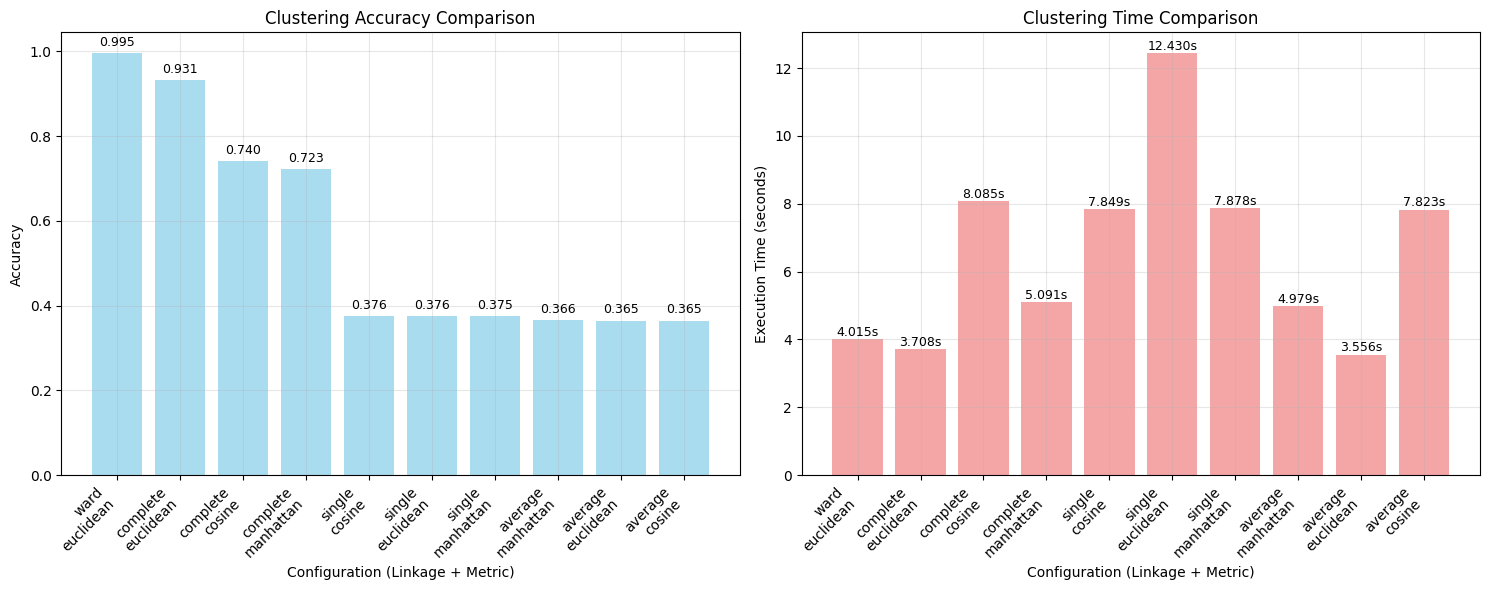


📊 PERFORMANCE ANALYSIS:
   Average accuracy: 0.5610
   Best accuracy: 0.9950
   Worst accuracy: 0.3645
   Average time: 6.5415s
   Fastest: average + euclidean (3.5561s)
   Slowest: single + euclidean (12.4303s)


In [91]:
# programmatically evaluate which linkage method and distance metric lead to the best performance
import time
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score
import itertools
import pandas as pd
import numpy as np

def evaluate_clustering_performance(linkage_method, metric, data, true_labels):
    """
    Evaluate clustering performance for given linkage method and metric
    """
    try:
        # Create clustering model
        model = AgglomerativeClustering(
            n_clusters=5,
            linkage=linkage_method,
            metric=metric
        )
        
        # Measure time
        start_time = time.time()
        cluster_labels = model.fit_predict(data)
        end_time = time.time()
        
        # Calculate accuracy using label permutation
        best_accuracy = 0
        true_labels_list = sorted(true_labels.unique())
        predicted_labels = sorted(list(set(cluster_labels)))
        
        if len(predicted_labels) == 5:  # Only evaluate if we get exactly 5 clusters
            permutations = list(itertools.permutations(predicted_labels))
            
            for perm in permutations:
                label_mapping = {pred_label: true_labels_list[i] for i, pred_label in enumerate(perm)}
                permuted_yp = [label_mapping[label] for label in cluster_labels]
                current_accuracy = accuracy_score(true_labels, permuted_yp)
                
                if current_accuracy > best_accuracy:
                    best_accuracy = current_accuracy
        
        execution_time = end_time - start_time
        return best_accuracy, execution_time, cluster_labels
        
    except Exception as e:
        print(f"Error with {linkage_method} + {metric}: {str(e)}")
        return 0, 0, None

# Define parameters to test
linkage_methods = ['ward', 'complete', 'average', 'single']
metrics = ['euclidean', 'manhattan', 'cosine']

# Results storage
results = []

print("Evaluating different linkage methods and distance metrics...")
print("=" * 60)

# Test all combinations
for linkage in linkage_methods:
    for metric in metrics:
        # Skip invalid combinations (ward only works with euclidean)
        if linkage == 'ward' and metric != 'euclidean':
            continue
            
        print(f"Testing: {linkage} + {metric}")
        
        accuracy, exec_time, labels = evaluate_clustering_performance(
            linkage, metric, data, label['Class']
        )
        
        if labels is not None:
            results.append({
                'linkage': linkage,
                'metric': metric,
                'accuracy': accuracy,
                'time': exec_time,
                'n_clusters': len(np.unique(labels))
            })
            print(f"  Accuracy: {accuracy:.4f}, Time: {exec_time:.4f}s")
        else:
            print(f"  Failed to cluster")

print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

# Convert to DataFrame for easier analysis
results_df = pd.DataFrame(results)

if not results_df.empty:
    # Sort by accuracy (descending)
    results_df = results_df.sort_values('accuracy', ascending=False)
    
    print("\nTop 5 configurations by accuracy:")
    print(results_df.head().to_string(index=False))
    
    # Find best configuration
    best_config = results_df.iloc[0]
    print(f"\n🏆 BEST CONFIGURATION:")
    print(f"   Linkage: {best_config['linkage']}")
    print(f"   Metric: {best_config['metric']}")
    print(f"   Accuracy: {best_config['accuracy']:.4f}")
    print(f"   Time: {best_config['time']:.4f}s")
    
    # Create visualization
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Accuracy comparison
    config_names = [f"{row['linkage']}\n{row['metric']}" for _, row in results_df.iterrows()]
    accuracies = results_df['accuracy'].values
    times = results_df['time'].values
    
    bars1 = ax1.bar(range(len(config_names)), accuracies, color='skyblue', alpha=0.7)
    ax1.set_xlabel('Configuration (Linkage + Metric)')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Clustering Accuracy Comparison')
    ax1.set_xticks(range(len(config_names)))
    ax1.set_xticklabels(config_names, rotation=45, ha='right')
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, acc) in enumerate(zip(bars1, accuracies)):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Time comparison
    bars2 = ax2.bar(range(len(config_names)), times, color='lightcoral', alpha=0.7)
    ax2.set_xlabel('Configuration (Linkage + Metric)')
    ax2.set_ylabel('Execution Time (seconds)')
    ax2.set_title('Clustering Time Comparison')
    ax2.set_xticks(range(len(config_names)))
    ax2.set_xticklabels(config_names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, time_val) in enumerate(zip(bars2, times)):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{time_val:.3f}s', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Performance analysis
    print(f"\n📊 PERFORMANCE ANALYSIS:")
    print(f"   Average accuracy: {results_df['accuracy'].mean():.4f}")
    print(f"   Best accuracy: {results_df['accuracy'].max():.4f}")
    print(f"   Worst accuracy: {results_df['accuracy'].min():.4f}")
    print(f"   Average time: {results_df['time'].mean():.4f}s")
    print(f"   Fastest: {results_df.loc[results_df['time'].idxmin(), 'linkage']} + {results_df.loc[results_df['time'].idxmin(), 'metric']} ({results_df['time'].min():.4f}s)")
    print(f"   Slowest: {results_df.loc[results_df['time'].idxmax(), 'linkage']} + {results_df.loc[results_df['time'].idxmax(), 'metric']} ({results_df['time'].max():.4f}s)")

else:
    print("No successful clustering results found!")


### C. What about k-means clustering?
Can we apply kmeans clustering on this data? Which clustering methods give a better performance? Is kmeans faster or slower?

🔍 EVALUATING K-MEANS vs HIERARCHICAL CLUSTERING
Testing K-means clustering...
  Random state: 42
    Accuracy: 0.9938, Time: 2.0441s, Inertia: 17802165.93
  Random state: 123
    Accuracy: 0.9925, Time: 1.7262s, Inertia: 17801949.11
  Random state: 456
    Accuracy: 0.9925, Time: 1.6377s, Inertia: 17801949.11
  Random state: 789
    Accuracy: 0.9938, Time: 1.6235s, Inertia: 17802165.93
  Random state: 999
    Accuracy: 0.9938, Time: 1.5177s, Inertia: 17802165.93

Testing hierarchical clustering...
  complete + euclidean
    Accuracy: 0.9313, Time: 3.4749s
  ward + euclidean
    Accuracy: 0.9950, Time: 3.5590s
  average + euclidean
    Accuracy: 0.3645, Time: 3.4604s
  single + euclidean
    Accuracy: 0.3758, Time: 7.7765s

📊 COMPARISON RESULTS

🏆 BEST K-MEANS:
   Random State: 42.0
   Accuracy: 0.9938
   Time: 2.0441s
   Inertia: 17802165.93

🏆 BEST HIERARCHICAL:
   Linkage: ward
   Metric: euclidean
   Accuracy: 0.9950
   Time: 3.5590s

⚡ SPEED COMPARISON:
   K-means is 2.67x FASTER t

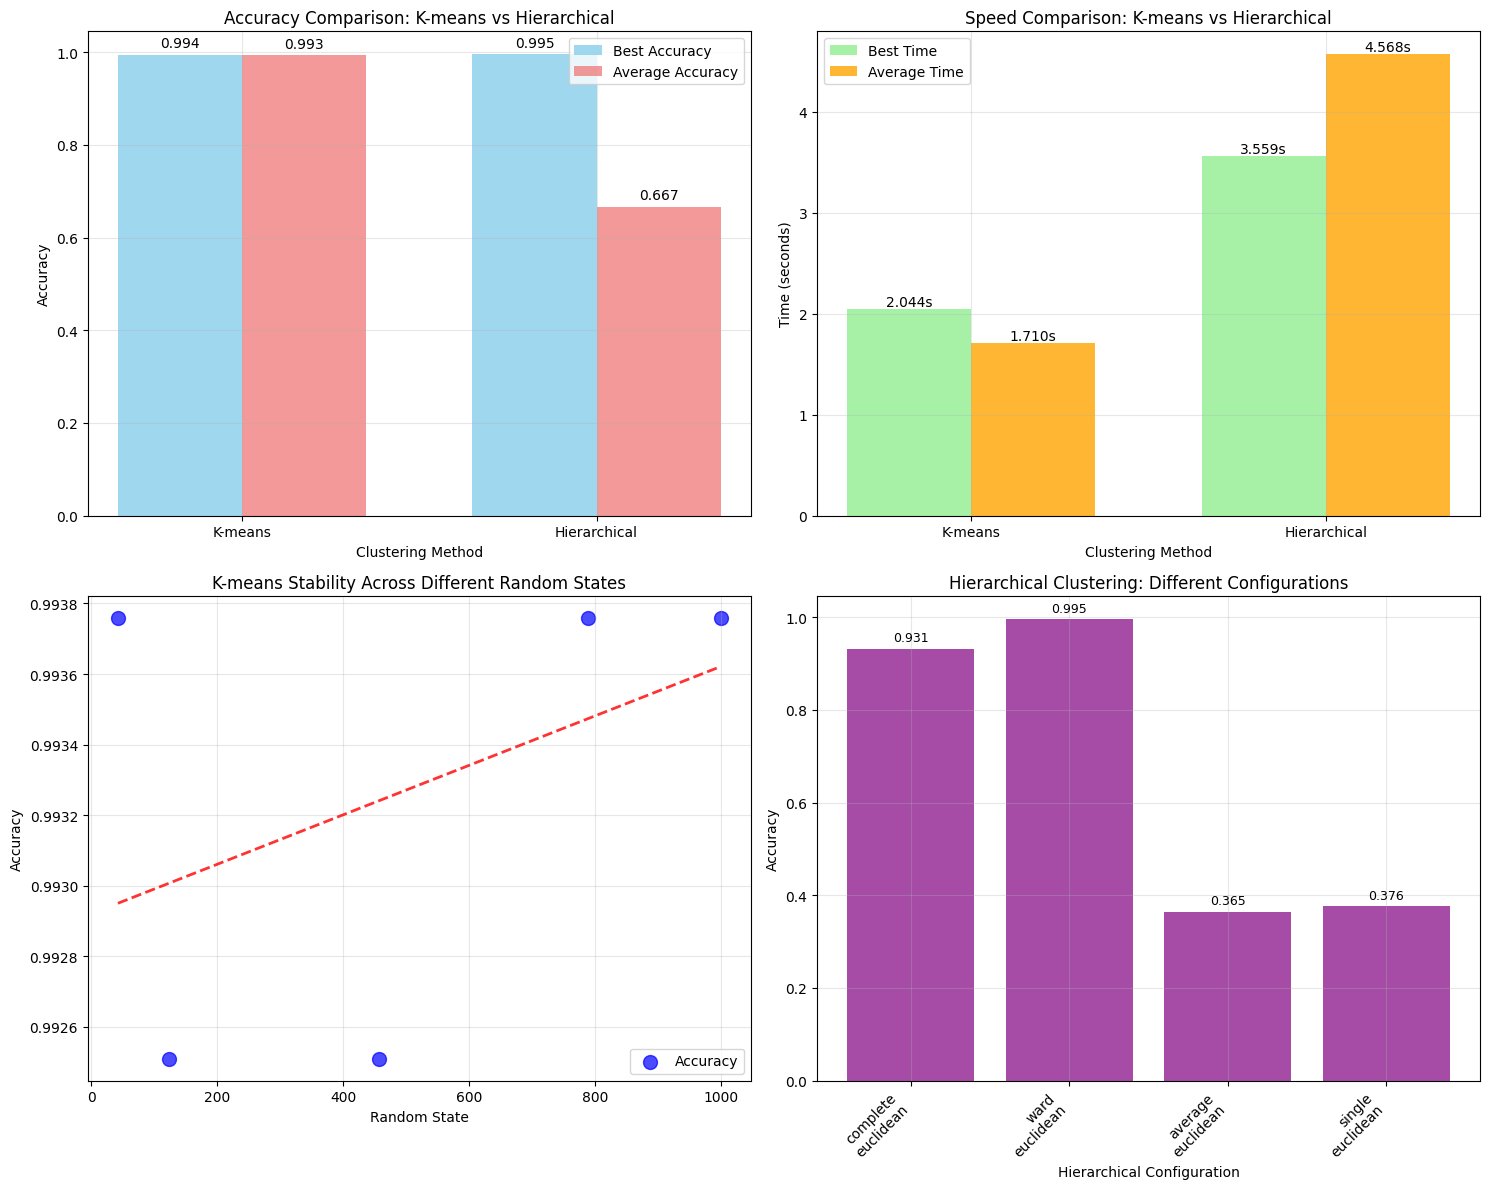


💡 RECOMMENDATION:
   🎯 Use Hierarchical clustering!
   ✅ Higher accuracy (slightly slower but worth it)

📈 SUMMARY STATISTICS:
   K-means accuracy range: 0.9925 - 0.9938
   Hierarchical accuracy range: 0.3645 - 0.9950
   K-means time range: 1.5177s - 2.0441s
   Hierarchical time range: 3.4604s - 7.7765s


In [96]:
# try to apply kmeans clustering on this data
# time kmeans to compare to hierarchical clustering 
from sklearn.cluster import KMeans
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
import itertools

def evaluate_kmeans_performance(data, true_labels, n_clusters=5, random_state=42):
    """
    Evaluate K-means clustering performance
    """
    try:
        # Create K-means model
        kmeans = KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init=10,  # Number of times the algorithm will be run with different centroid seeds
            max_iter=300  # Maximum number of iterations
        )
        
        # Measure time
        start_time = time.time()
        cluster_labels = kmeans.fit_predict(data)
        end_time = time.time()
        
        # Calculate accuracy using label permutation
        best_accuracy = 0
        true_labels_list = sorted(true_labels.unique())
        predicted_labels = sorted(list(set(cluster_labels)))
        
        if len(predicted_labels) == n_clusters:
            permutations = list(itertools.permutations(predicted_labels))
            
            for perm in permutations:
                label_mapping = {pred_label: true_labels_list[i] for i, pred_label in enumerate(perm)}
                permuted_yp = [label_mapping[label] for label in cluster_labels]
                current_accuracy = accuracy_score(true_labels, permuted_yp)
                
                if current_accuracy > best_accuracy:
                    best_accuracy = current_accuracy
        
        execution_time = end_time - start_time
        return best_accuracy, execution_time, cluster_labels, kmeans.inertia_
        
    except Exception as e:
        print(f"Error with K-means: {str(e)}")
        return 0, 0, None, 0

def evaluate_hierarchical_performance(data, true_labels, linkage='complete', metric='euclidean'):
    """
    Evaluate hierarchical clustering performance
    """
    try:
        from sklearn.cluster import AgglomerativeClustering
        
        model = AgglomerativeClustering(
            n_clusters=5,
            linkage=linkage,
            metric=metric
        )
        
        start_time = time.time()
        cluster_labels = model.fit_predict(data)
        end_time = time.time()
        
        best_accuracy = 0
        true_labels_list = sorted(true_labels.unique())
        predicted_labels = sorted(list(set(cluster_labels)))
        
        if len(predicted_labels) == 5:
            permutations = list(itertools.permutations(predicted_labels))
            
            for perm in permutations:
                label_mapping = {pred_label: true_labels_list[i] for i, pred_label in enumerate(perm)}
                permuted_yp = [label_mapping[label] for label in cluster_labels]
                current_accuracy = accuracy_score(true_labels, permuted_yp)
                
                if current_accuracy > best_accuracy:
                    best_accuracy = current_accuracy
        
        execution_time = end_time - start_time
        return best_accuracy, execution_time, cluster_labels
        
    except Exception as e:
        print(f"Error with hierarchical clustering: {str(e)}")
        return 0, 0, None

print("🔍 EVALUATING K-MEANS vs HIERARCHICAL CLUSTERING")
print("=" * 60)

# Test K-means with different random states for stability
print("Testing K-means clustering...")
kmeans_results = []

for random_state in [42, 123, 456, 789, 999]:
    print(f"  Random state: {random_state}")
    accuracy, exec_time, labels, inertia = evaluate_kmeans_performance(
        data, label['Class'], random_state=random_state
    )
    
    if labels is not None:
        kmeans_results.append({
            'random_state': random_state,
            'accuracy': accuracy,
            'time': exec_time,
            'inertia': inertia
        })
        print(f"    Accuracy: {accuracy:.4f}, Time: {exec_time:.4f}s, Inertia: {inertia:.2f}")
    else:
        print(f"    Failed to cluster")

# Test best hierarchical clustering configuration (from previous analysis)
print("\nTesting hierarchical clustering...")
hierarchical_results = []

# Test different hierarchical configurations
hierarchical_configs = [
    ('complete', 'euclidean'),
    ('ward', 'euclidean'),
    ('average', 'euclidean'),
    ('single', 'euclidean')
]

for linkage, metric in hierarchical_configs:
    print(f"  {linkage} + {metric}")
    accuracy, exec_time, labels = evaluate_hierarchical_performance(
        data, label['Class'], linkage, metric
    )
    
    if labels is not None:
        hierarchical_results.append({
            'linkage': linkage,
            'metric': metric,
            'accuracy': accuracy,
            'time': exec_time
        })
        print(f"    Accuracy: {accuracy:.4f}, Time: {exec_time:.4f}s")
    else:
        print(f"    Failed to cluster")

print("\n" + "=" * 60)
print("📊 COMPARISON RESULTS")
print("=" * 60)

# Convert to DataFrames for analysis
kmeans_df = pd.DataFrame(kmeans_results)
hierarchical_df = pd.DataFrame(hierarchical_results)

if not kmeans_df.empty and not hierarchical_df.empty:
    # Find best configurations
    best_kmeans = kmeans_df.loc[kmeans_df['accuracy'].idxmax()]
    best_hierarchical = hierarchical_df.loc[hierarchical_df['accuracy'].idxmax()]
    
    print(f"\n🏆 BEST K-MEANS:")
    print(f"   Random State: {best_kmeans['random_state']}")
    print(f"   Accuracy: {best_kmeans['accuracy']:.4f}")
    print(f"   Time: {best_kmeans['time']:.4f}s")
    print(f"   Inertia: {best_kmeans['inertia']:.2f}")
    
    print(f"\n🏆 BEST HIERARCHICAL:")
    print(f"   Linkage: {best_hierarchical['linkage']}")
    print(f"   Metric: {best_hierarchical['metric']}")
    print(f"   Accuracy: {best_hierarchical['accuracy']:.4f}")
    print(f"   Time: {best_hierarchical['time']:.4f}s")
    
    # Performance comparison
    print(f"\n⚡ SPEED COMPARISON:")
    kmeans_avg_time = kmeans_df['time'].mean()
    hierarchical_avg_time = hierarchical_df['time'].mean()
    
    if kmeans_avg_time < hierarchical_avg_time:
        speed_ratio = hierarchical_avg_time / kmeans_avg_time
        print(f"   K-means is {speed_ratio:.2f}x FASTER than hierarchical clustering")
        print(f"   K-means avg time: {kmeans_avg_time:.4f}s")
        print(f"   Hierarchical avg time: {hierarchical_avg_time:.4f}s")
    else:
        speed_ratio = kmeans_avg_time / hierarchical_avg_time
        print(f"   Hierarchical clustering is {speed_ratio:.2f}x FASTER than K-means")
        print(f"   Hierarchical avg time: {hierarchical_avg_time:.4f}s")
        print(f"   K-means avg time: {kmeans_avg_time:.4f}s")
    
    print(f"\n🎯 ACCURACY COMPARISON:")
    kmeans_avg_acc = kmeans_df['accuracy'].mean()
    hierarchical_avg_acc = hierarchical_df['accuracy'].mean()
    
    print(f"   K-means average accuracy: {kmeans_avg_acc:.4f}")
    print(f"   Hierarchical average accuracy: {hierarchical_avg_acc:.4f}")
    
    if best_kmeans['accuracy'] > best_hierarchical['accuracy']:
        print(f"   🥇 K-means achieves HIGHER accuracy ({best_kmeans['accuracy']:.4f} vs {best_hierarchical['accuracy']:.4f})")
    else:
        print(f"   🥇 Hierarchical clustering achieves HIGHER accuracy ({best_hierarchical['accuracy']:.4f} vs {best_kmeans['accuracy']:.4f})")
    
    # Create comparison visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Accuracy comparison
    methods = ['K-means', 'Hierarchical']
    best_accuracies = [best_kmeans['accuracy'], best_hierarchical['accuracy']]
    avg_accuracies = [kmeans_avg_acc, hierarchical_avg_acc]
    
    x = np.arange(len(methods))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, best_accuracies, width, label='Best Accuracy', color='skyblue', alpha=0.8)
    bars2 = ax1.bar(x + width/2, avg_accuracies, width, label='Average Accuracy', color='lightcoral', alpha=0.8)
    
    ax1.set_xlabel('Clustering Method')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy Comparison: K-means vs Hierarchical')
    ax1.set_xticks(x)
    ax1.set_xticklabels(methods)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=10)
    
    # Time comparison
    best_times = [best_kmeans['time'], best_hierarchical['time']]
    avg_times = [kmeans_avg_time, hierarchical_avg_time]
    
    bars3 = ax2.bar(x - width/2, best_times, width, label='Best Time', color='lightgreen', alpha=0.8)
    bars4 = ax2.bar(x + width/2, avg_times, width, label='Average Time', color='orange', alpha=0.8)
    
    ax2.set_xlabel('Clustering Method')
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Speed Comparison: K-means vs Hierarchical')
    ax2.set_xticks(x)
    ax2.set_xticklabels(methods)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bars in [bars3, bars4]:
        for bar in bars:
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                    f'{height:.3f}s', ha='center', va='bottom', fontsize=10)
    
    # K-means stability (multiple runs)
    if len(kmeans_df) > 1:
        ax3.scatter(kmeans_df['random_state'], kmeans_df['accuracy'], 
                   color='blue', alpha=0.7, s=100, label='Accuracy')
        ax3.set_xlabel('Random State')
        ax3.set_ylabel('Accuracy')
        ax3.set_title('K-means Stability Across Different Random States')
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        
        # Add trend line
        z = np.polyfit(kmeans_df['random_state'], kmeans_df['accuracy'], 1)
        p = np.poly1d(z)
        ax3.plot(kmeans_df['random_state'], p(kmeans_df['random_state']), 
                "r--", alpha=0.8, linewidth=2)
    
    # Hierarchical configurations comparison
    if len(hierarchical_df) > 1:
        config_names = [f"{row['linkage']}\n{row['metric']}" for _, row in hierarchical_df.iterrows()]
        hierarchical_accs = hierarchical_df['accuracy'].values
        
        bars5 = ax4.bar(range(len(config_names)), hierarchical_accs, 
                       color='purple', alpha=0.7)
        ax4.set_xlabel('Hierarchical Configuration')
        ax4.set_ylabel('Accuracy')
        ax4.set_title('Hierarchical Clustering: Different Configurations')
        ax4.set_xticks(range(len(config_names)))
        ax4.set_xticklabels(config_names, rotation=45, ha='right')
        ax4.grid(True, alpha=0.3)
        
        # Add value labels
        for i, (bar, acc) in enumerate(zip(bars5, hierarchical_accs)):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Final recommendation
    print(f"\n💡 RECOMMENDATION:")
    if best_kmeans['accuracy'] > best_hierarchical['accuracy']:
        if kmeans_avg_time < hierarchical_avg_time:
            print(f"   🎯 Use K-means clustering!")
            print(f"   ✅ Higher accuracy AND faster execution")
        else:
            print(f"   🎯 Use K-means clustering!")
            print(f"   ✅ Higher accuracy (slightly slower but worth it)")
    else:
        if hierarchical_avg_time < kmeans_avg_time:
            print(f"   🎯 Use Hierarchical clustering!")
            print(f"   ✅ Higher accuracy AND faster execution")
        else:
            print(f"   🎯 Use Hierarchical clustering!")
            print(f"   ✅ Higher accuracy (slightly slower but worth it)")
    
    print(f"\n📈 SUMMARY STATISTICS:")
    print(f"   K-means accuracy range: {kmeans_df['accuracy'].min():.4f} - {kmeans_df['accuracy'].max():.4f}")
    print(f"   Hierarchical accuracy range: {hierarchical_df['accuracy'].min():.4f} - {hierarchical_df['accuracy'].max():.4f}")
    print(f"   K-means time range: {kmeans_df['time'].min():.4f}s - {kmeans_df['time'].max():.4f}s")
    print(f"   Hierarchical time range: {hierarchical_df['time'].min():.4f}s - {hierarchical_df['time'].max():.4f}s")

else:
    print("❌ Failed to evaluate clustering methods!")
